In [1]:
# Install windrose (for wind rose plots)
!pip install windrose

# Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from windrose import WindroseAxes

print("Libraries loaded!")


Libraries loaded!


In [4]:
# Upload your CSV and change this path
file_path = '/content/benin-malanville.csv'

# Load CSV
df = pd.read_csv(file_path)

# Convert timestamp to datetime and set as index
df['Timestamp'] = pd.to_datetime(df['Timestamp'])
df.set_index('Timestamp', inplace=True)

print("Data loaded. First 5 rows:")
df.head()


Data loaded. First 5 rows:


,GHI,DNI,DHI,ModA,ModB,Tamb,RH,WS,WSgust,WSstdev,WD,WDstdev,BP,Cleaning,Precipitation,TModA,TModB,Comments
Timestamp,,,,,,,,,,,,,,,,,,
2021-08-09 00:01:00,-1.2,-0.2,-1.1,0.0,0.0,26.2,93.4,0.0,0.4,0.1,122.1,0.0,998.0,0.0,0.0,26.3,26.2,NaN
2021-08-09 00:02:00,-1.1,-0.2,-1.1,0.0,0.0,26.2,93.6,0.0,0.0,0.0,0.0,0.0,998.0,0.0,0.0,26.3,26.2,NaN
2021-08-09 00:03:00,-1.1,-0.2,-1.1,0.0,0.0,26.2,93.7,0.3,1.1,0.5,124.6,1.5,997.0,0.0,0.0,26.4,26.2,NaN
2021-08-09 00:04:00,-1.1,-0.1,-1.0,0.0,0.0,26.2,93.3,0.2,0.7,0.4,120.3,1.3,997.0,0.0,0.0,26.4,26.3,NaN
2021-08-09 00:05:00,-1.0,-0.1,-1.0,0.0,0.0,26.2,93.3,0.1,0.7,0.3,113.2,1.0,997.0,0.0,0.0,26.4,26.3,NaN


In [5]:
# Numeric summary
print("Summary Statistics:")
display(df.describe())

# Missing values
missing = df.isna().sum()
missing_percent = (missing / len(df)) * 100

print("Columns with missing values:")
display(missing[missing > 0])

print("Columns with >5% missing:")
display(missing_percent[missing_percent > 5])


Summary Statistics:


,GHI,DNI,DHI,ModA,ModB,Tamb,RH,WS,WSgust,WSstdev,WD,WDstdev,BP,Cleaning,Precipitation,TModA,TModB,Comments
count,59539.000000,59538.000000,59538.000000,59538.000000,59538.000000,59538.000000,59538.000000,59538.000000,59538.000000,59538.000000,59538.000000,59538.000000,59538.000000,59538.000000,59538.000000,59538.000000,59538.000000,0.0
mean,204.907536,103.805585,122.137148,193.274351,193.330475,26.750380,85.256251,1.679015,2.310889,0.431157,166.070540,7.127394,995.376348,0.000941,0.006268,33.943174,31.964458,NaN
std,307.245962,218.962733,170.943363,290.280434,290.385332,3.215732,12.979953,1.551811,1.944085,0.284812,107.151052,5.795403,1.820082,0.030655,0.073956,12.849047,10.602514,NaN
min,-7.300000,-3.000000,-6.200000,0.000000,0.000000,20.300000,44.800000,0.000000,0.000000,0.000000,0.000000,0.000000,989.000000,0.000000,0.000000,20.800000,20.300000,NaN
25%,-1.400000,-0.200000,-1.300000,0.000000,0.000000,24.200000,76.200000,0.300000,1.100000,0.300000,61.800000,1.400000,994.000000,0.000000,0.000000,24.700000,24.200000,NaN
50%,2.900000,-0.100000,2.900000,4.300000,4.300000,26.200000,89.800000,1.500000,2.100000,0.500000,198.350000,7.200000,995.000000,0.000000,0.000000,27.200000,26.600000,NaN
75%,341.900000,33.900000,230.400000,317.250000,317.250000,29.000000,95.900000,2.600000,3.400000,0.600000,245.300000,10.800000,997.000000,0.000000,0.000000,41.500000,38.600000,NaN
max,1413.000000,904.000000,715.700000,1342.300000,1342.300000,36.800000,100.000000,15.900000,19.800000,3.700000,360.000000,77.300000,1001.000000,1.000000,2.500000,81.000000,69.800000,NaN


Columns with missing values:


,0
DNI,1
DHI,1
ModA,1
ModB,1
Tamb,1
RH,1
WS,1
WSgust,1
WSstdev,1
WD,1


Columns with >5% missing:


,0
Comments,100.0


In [6]:
cols = ['GHI','DNI','DHI','ModA','ModB','WS','WSgust']

# Compute Z-scores
z_scores = np.abs(stats.zscore(df[cols], nan_policy='omit'))

# Flag rows with Z-score > 3
outliers = (z_scores > 3).any(axis=1)
print(f"Number of outlier rows: {outliers.sum()}")

# View outliers
df_outliers = df[outliers]
display(df_outliers)


Number of outlier rows: 2812


,GHI,DNI,DHI,ModA,ModB,Tamb,RH,WS,WSgust,WSstdev,WD,WDstdev,BP,Cleaning,Precipitation,TModA,TModB,Comments
Timestamp,,,,,,,,,,,,,,,,,,
2021-08-09 10:38:00,915.0,767.5,250.8,841.0,845.0,29.2,73.3,4.0,5.1,0.7,219.8,9.0,999.0,0.0,0.0,62.6,52.7,NaN
2021-08-09 10:39:00,945.0,769.8,278.6,871.0,876.0,29.0,73.9,3.8,5.4,0.9,226.1,10.7,999.0,0.0,0.0,62.4,52.5,NaN
2021-08-09 10:41:00,934.0,774.6,258.6,858.0,862.0,28.8,74.2,3.7,4.4,0.5,220.3,13.1,999.0,0.0,0.0,60.4,51.2,NaN
2021-08-09 10:46:00,958.0,778.8,269.5,881.0,886.0,29.2,73.4,2.2,3.6,0.8,208.4,19.1,999.0,0.0,0.0,57.3,49.1,NaN
2021-08-09 10:47:00,964.0,771.0,282.4,892.0,897.0,29.4,72.7,4.0,4.6,0.5,214.9,12.0,999.0,0.0,0.0,58.9,49.8,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2021-09-18 13:42:00,983.0,763.1,241.3,958.0,958.0,33.4,59.0,3.6,4.4,0.5,244.7,10.1,995.0,0.0,0.0,62.3,60.5,NaN
2021-09-18 13:43:00,980.0,762.5,239.8,955.0,956.0,33.2,57.0,2.1,3.1,0.8,254.9,20.8,995.0,0.0,0.0,61.4,59.9,NaN
2021-09-18 13:44:00,979.0,761.7,240.7,955.0,955.0,33.2,56.2,2.0,3.1,0.7,238.9,21.2,995.0,0.0,0.0,61.3,60.0,NaN


In [7]:
# Make a copy to clean
df_clean = df.copy()

# Replace outliers with median
for col in cols:
    median = df_clean[col].median()
    df_clean[col] = df_clean[col].mask(z_scores[:, cols.index(col)] > 3, median)

# Fill missing values with median
for col in cols:
    df_clean[col] = df_clean[col].fillna(df_clean[col].median())

print("Data cleaned successfully.")
df_clean.describe()


Data cleaned successfully.


,GHI,DNI,DHI,ModA,ModB,Tamb,RH,WS,WSgust,WSstdev,WD,WDstdev,BP,Cleaning,Precipitation,TModA,TModB,Comments
count,59539.000000,59539.000000,59539.000000,59539.000000,59539.00000,59538.000000,59538.000000,59539.000000,59539.000000,59538.000000,59538.000000,59538.000000,59538.000000,59538.000000,59538.000000,59538.000000,59538.000000,0.0
mean,198.510198,80.111134,119.565826,186.889622,186.88375,26.750380,85.256251,1.603151,2.208722,0.431157,166.070540,7.127394,995.376348,0.000941,0.006268,33.943174,31.964458,NaN
std,298.890385,181.173906,167.769697,281.893553,281.90870,3.215732,12.979953,1.365143,1.687263,0.284812,107.151052,5.795403,1.820082,0.030655,0.073956,12.849047,10.602514,NaN
min,-7.300000,-3.000000,-6.200000,0.000000,0.00000,20.300000,44.800000,0.000000,0.000000,0.000000,0.000000,0.000000,989.000000,0.000000,0.000000,20.800000,20.300000,NaN
25%,-1.400000,-0.200000,-1.300000,0.000000,0.00000,24.200000,76.200000,0.300000,1.100000,0.300000,61.800000,1.400000,994.000000,0.000000,0.000000,24.700000,24.200000,NaN
50%,2.900000,-0.100000,2.900000,4.300000,4.30000,26.200000,89.800000,1.500000,2.100000,0.500000,198.350000,7.200000,995.000000,0.000000,0.000000,27.200000,26.600000,NaN
75%,329.700000,13.000000,226.000000,305.350000,305.10000,29.000000,95.900000,2.500000,3.400000,0.600000,245.300000,10.800000,997.000000,0.000000,0.000000,41.500000,38.600000,NaN
max,1126.000000,760.600000,634.900000,1064.000000,1064.00000,36.800000,100.000000,6.300000,7.900000,3.700000,360.000000,77.300000,1001.000000,1.000000,2.500000,81.000000,69.800000,NaN


In [8]:
clean_file = '/content/benin_clean.csv'
df_clean.to_csv(clean_file, index=False)
print(f"Cleaned CSV saved to {clean_file}")


Cleaned CSV saved to /content/benin_clean.csv


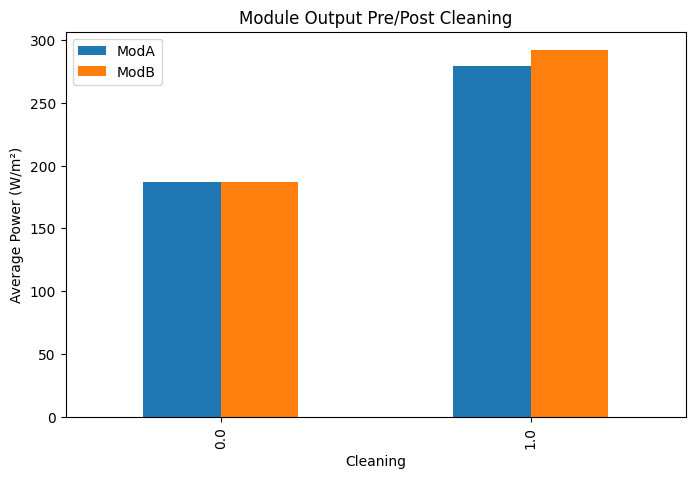

In [9]:
if 'Cleaning' in df_clean.columns:
    df_clean.groupby('Cleaning')[['ModA','ModB']].mean().plot(kind='bar', figsize=(8,5))
    plt.title("Module Output Pre/Post Cleaning")
    plt.ylabel("Average Power (W/m²)")
    plt.show()


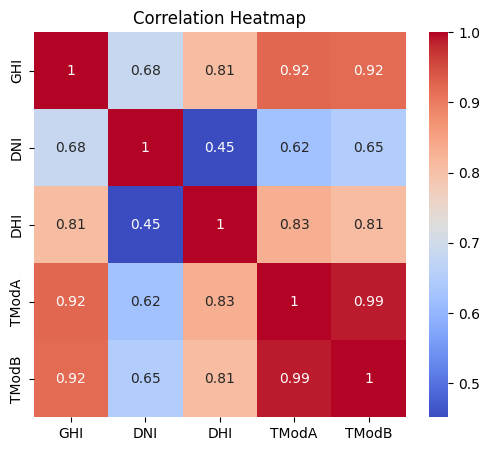

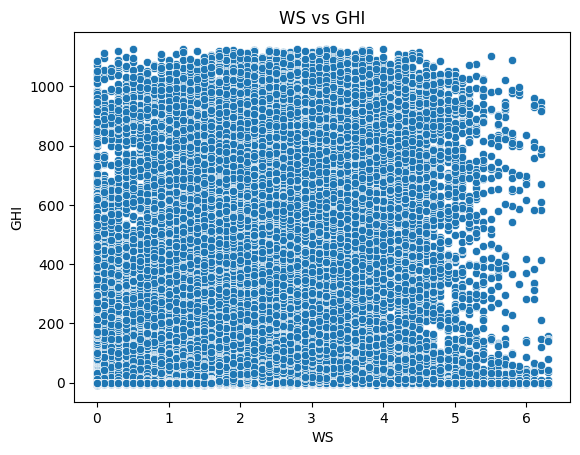

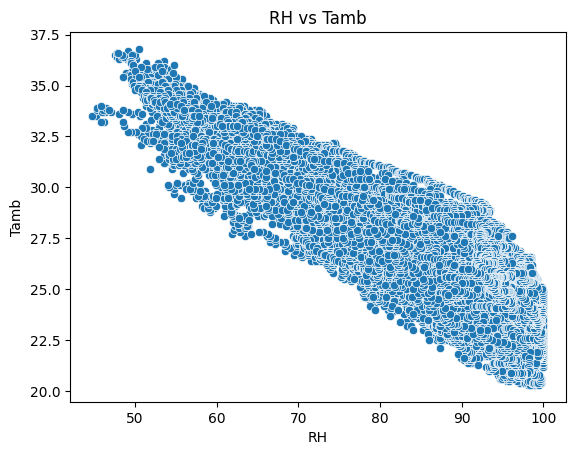

In [10]:
# Correlation heatmap
corr_cols = ['GHI','DNI','DHI','TModA','TModB']
plt.figure(figsize=(6,5))
sns.heatmap(df_clean[corr_cols].corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

# Scatter plots
sns.scatterplot(data=df_clean, x='WS', y='GHI')
plt.title("WS vs GHI")
plt.show()

sns.scatterplot(data=df_clean, x='RH', y='Tamb')
plt.title("RH vs Tamb")
plt.show()


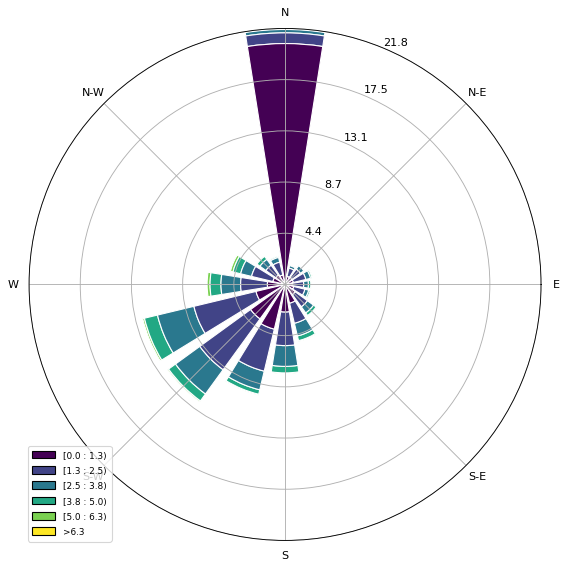

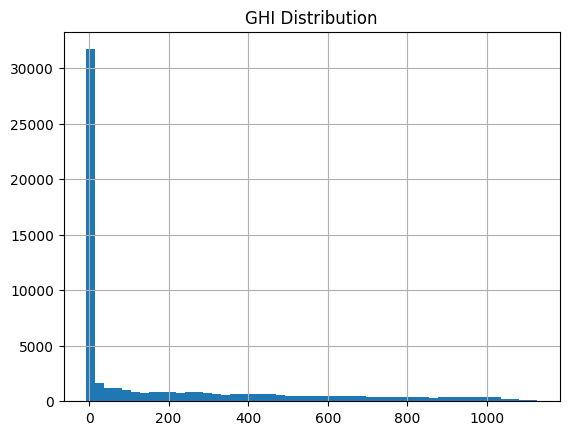

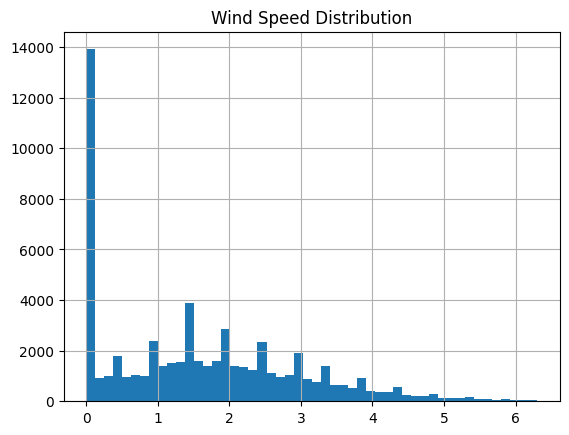

In [11]:
# Wind rose
if 'WD' in df_clean.columns and 'WS' in df_clean.columns:
    ax = WindroseAxes.from_ax()
    ax.bar(df_clean['WD'], df_clean['WS'], normed=True, opening=0.8, edgecolor='white')
    ax.set_legend()
    plt.show()

# Histograms
df_clean['GHI'].hist(bins=50)
plt.title("GHI Distribution")
plt.show()

df_clean['WS'].hist(bins=50)
plt.title("Wind Speed Distribution")
plt.show()


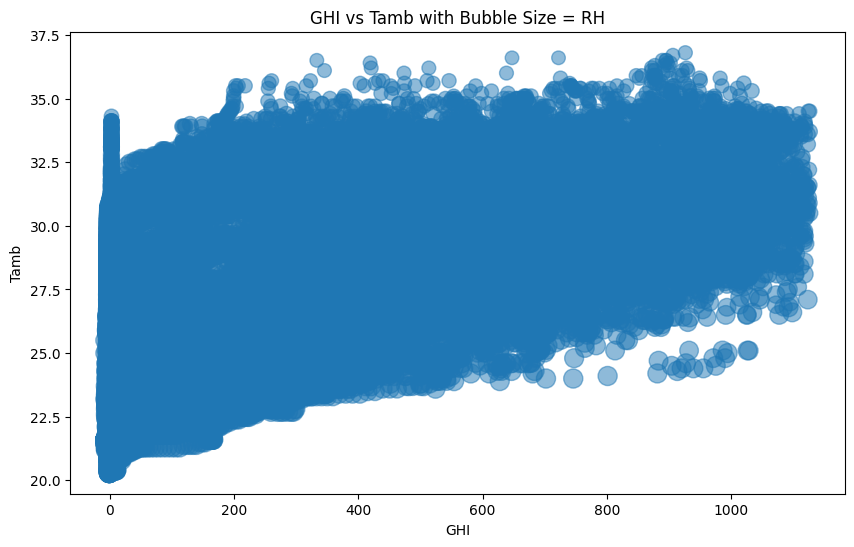

In [12]:
if 'RH' in df_clean.columns:
    plt.figure(figsize=(10,6))
    plt.scatter(df_clean['GHI'], df_clean['Tamb'], s=df_clean['RH']*2, alpha=0.5)
    plt.xlabel('GHI')
    plt.ylabel('Tamb')
    plt.title('GHI vs Tamb with Bubble Size = RH')
    plt.show()
